# ViT backbone study

In [1]:
import os, sys, subprocess
from getpass import getpass

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "real-video"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [2]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "KEY"

## **Download DATASET**

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Drive mounted.
Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
ULAL_DATASET_ROOT = /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/
ULAL_OUTPUT_ROOT  = /content/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete.


### Imports

In [4]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
Classes   : base=10 task1=5 task2=5


42

## **Preprocess data**

In [5]:
base_split = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)
clashes    = describe_group_split(base_split, cfg.SELECTED_CLASSES)

split      clips   percent  clips/class
---------------------------------------
train        953     71.7%         95.3
val          165     12.4%         16.5
test         212     15.9%         21.2
---------------------------------------
TOTAL       1330                  133.0

groups: 250   groups in >1 split: 0
OK - group-disjoint.


### Clip preprocessing

In [6]:
# BASE
preprocess_group_split(base_split, cfg.SELECTED_CLASSES, output_root=cfg.BASE_ROOT, max_samples=cfg.MAX_SAMPLES)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_base


### Label encoding

In [7]:
class_to_idx = {cls_name: i for i, cls_name in enumerate(cfg.SELECTED_CLASSES)}
print(class_to_idx)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9}


## **DataLoaders**

In [8]:
base_train = UCF101Clips(os.path.join(cfg.BASE_ROOT, "train"), class_to_idx=class_to_idx)
base_val   = UCF101Clips(os.path.join(cfg.BASE_ROOT, "val"),   class_to_idx=class_to_idx)
base_test  = UCF101Clips(os.path.join(cfg.BASE_ROOT, "test"),  class_to_idx=class_to_idx)

train_loader = DataLoader(base_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(base_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(base_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

print(f"train {len(base_train)}  val {len(base_val)}  test {len(base_test)}")

train 953  val 165  test 212


## **Training setup**

In [9]:
EPOCHS = 5
TRIALS = []

## **ViT-B/16 + LSTM**

In [10]:
vit = ViTLSTM().to(device)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 175MB/s] 


### Architectural inspection

In [11]:
summary(vit, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                             Output Shape              Param #
ViTLSTM                                            [1, 10]                   --
├─VisionTransformer: 1-1                           [16, 768]                 768
│    └─Conv2d: 2-1                                 [16, 768, 14, 14]         (590,592)
│    └─Encoder: 2-2                                [16, 197, 768]            151,296
│    │    └─Dropout: 3-1                           [16, 197, 768]            --
│    │    └─Sequential: 3-2                        [16, 197, 768]            85,054,464
│    │    └─LayerNorm: 3-3                         [16, 197, 768]            (1,536)
│    └─Identity: 2-3                               [16, 768]                 --
├─LSTM: 1-2                                        [1, 16, 256]              1,576,960
├─Linear: 1-3                                      [1, 10]                   2,570
Total params: 87,378,186
Trainable params: 15,755,274
Non-trainable params: 71,

### Training

In [12]:
set_seed(cfg.SEED)
hist_vit = train_model(vit, train_loader, val_loader, num_epochs=EPOCHS, device=device)

Epoch [1/5] | Train Acc: 0.8489 Loss: 0.7699 | Val Acc: 0.9515 Loss: 0.1928


Epoch [2/5] | Train Acc: 0.9864 Loss: 0.0676 | Val Acc: 0.9273 Loss: 0.2761


Epoch [3/5] | Train Acc: 0.9927 Loss: 0.0363 | Val Acc: 0.9879 Loss: 0.0460


Epoch [4/5] | Train Acc: 0.9937 Loss: 0.0275 | Val Acc: 0.9758 Loss: 0.0597


Epoch [5/5] | Train Acc: 0.9969 Loss: 0.0172 | Val Acc: 0.9758 Loss: 0.0598


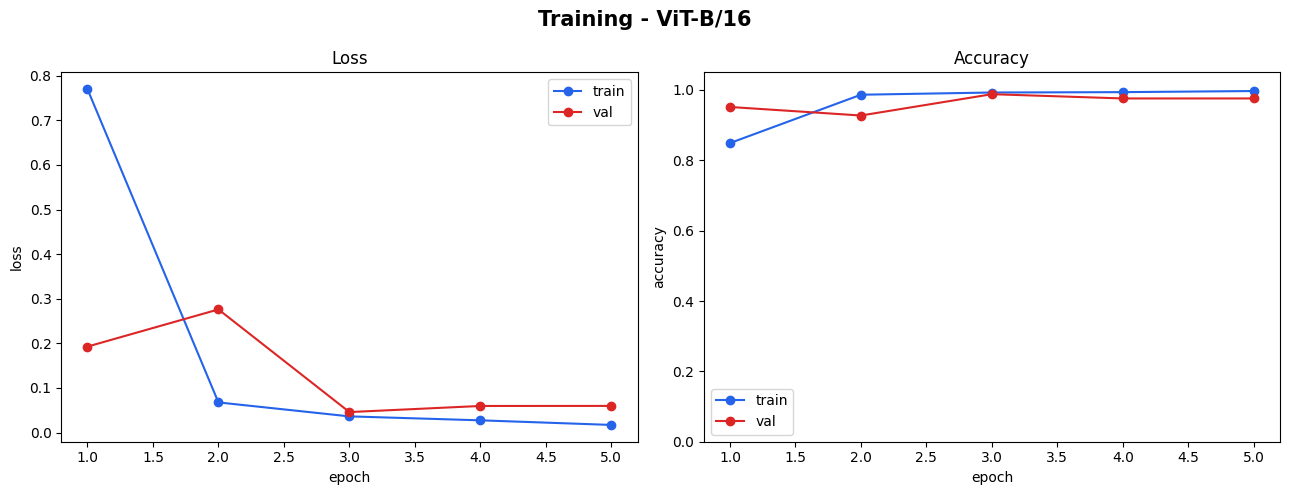

In [13]:
plot_training_results(hist_vit, task_name="ViT-B/16")

### Test

In [14]:
acc_vit, preds_vit, labels_vit = test_model(vit, test_loader, device)

Test Accuracy: 0.9434


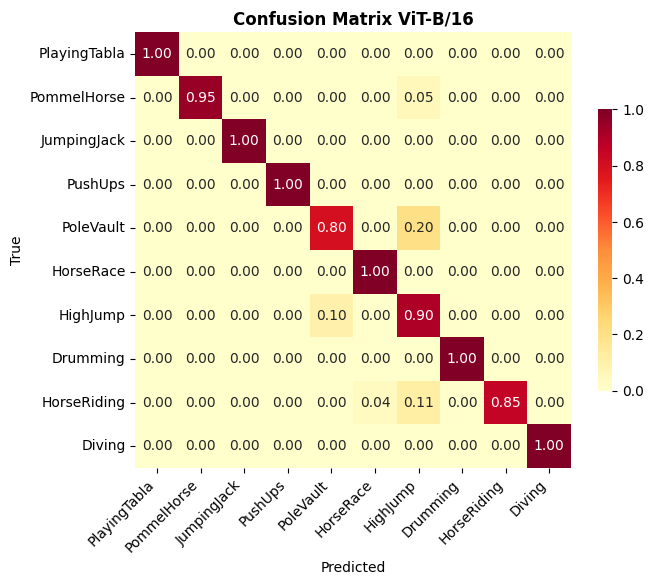

In [15]:
plot_confusion_matrix(labels_vit, preds_vit, num_classes=len(cfg.SELECTED_CLASSES), classes_list=cfg.SELECTED_CLASSES, name="ViT-B/16")

### Class-wise metrics

In [16]:
print_detailed_metrics(labels_vit, preds_vit, num_classes=len(cfg.SELECTED_CLASSES), classes_list=cfg.SELECTED_CLASSES)


METRICS FOR 10 CLASSES
  Accuracy : 0.9434
  F1-Score : 0.9453

PER-CLASS REPORT
              precision    recall  f1-score   support

PlayingTabla       1.00      1.00      1.00        17
 PommelHorse       1.00      0.95      0.97        19
 JumpingJack       1.00      1.00      1.00        19
     PushUps       1.00      1.00      1.00        16
   PoleVault       0.91      0.80      0.85        25
   HorseRace       0.95      1.00      0.98        20
    HighJump       0.68      0.90      0.78        21
    Drumming       1.00      1.00      1.00        25
 HorseRiding       1.00      0.85      0.92        27
      Diving       1.00      1.00      1.00        23

    accuracy                           0.94       212
   macro avg       0.95      0.95      0.95       212
weighted avg       0.95      0.94      0.95       212



In [17]:
params_vit    = sum(p.numel() for p in vit.parameters())
trainable_vit = sum(p.numel() for p in vit.parameters() if p.requires_grad)
print(f"parameters: {params_vit / 1e6:.1f}M, trainable: {trainable_vit / 1e6:.1f}M")
TRIALS.append({"name": "ViT-B/16", "test_acc": acc_vit, "best_val": max(hist_vit["val_accs"]), "params_M": params_vit / 1e6, "size_MB": params_vit * 4 / 1e6, "ms_per_clip": measure_latency(vit, test_loader, device)})

parameters: 87.4M, trainable: 15.8M


## **Compare with the CNN backbones**

In [18]:
# CNN results saved by backbone_transfer.ipynb (same split, same budget)
cnn_path = f"{cfg.RESULTS_DIR}/stage2_choose_model.json"
if os.path.exists(cnn_path):
    with open(cnn_path) as f:
        cnn_trials = json.load(f)
    print(f"loaded {len(cnn_trials)} CNN results from {cnn_path}")
else:
    cnn_trials = []
    print(f"no CNN results at {cnn_path}: run backbone_transfer.ipynb first")

results_df = pd.DataFrame(cnn_trials + TRIALS).sort_values("test_acc", ascending=False).reset_index(drop=True)
results_df

no CNN results at /content/drive/MyDrive/apai/results/stage2_choose_model.json: run backbone_transfer.ipynb first


,name,test_acc,best_val,params_M,size_MB,ms_per_clip
0,ViT-B/16,0.943396,0.987879,87.378186,349.512744,184.152716


## **Save**

In [19]:
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
with open(f"{cfg.RESULTS_DIR}/stage2_vit.json", "w") as f:
    json.dump(TRIALS, f, indent=2)
print(f"saved results -> {cfg.RESULTS_DIR}/stage2_vit.json")

saved results -> /content/drive/MyDrive/apai/results/stage2_vit.json


## **Recap**

- ViT-B/16 (ImageNet) + a 2-layer LSTM, trained on the 10 base classes with the same group-disjoint split, loaders and budget as the CNN backbones (5 epochs, Adam, lr 1e-4).
- Only the last 2 of the 12 encoder blocks, the LSTM and the head are trained (15.8M of 87.4M parameters).
- The comparison table puts the ViT next to the CNN backbones on the same test set. Its test accuracy goes in the Group-disjoint column of the paper's backbone table.
- An earlier run on UCF101's shipped split (which leaks) reached 99.4%; that version is on the main branch.